# 📘 Proyecto: Predicción de Primas de Seguro

Este proyecto tiene como objetivo predecir el costo de una prima médica usando un conjunto de datos con información demográfica y de estilo de vida. Se aplican técnicas de análisis exploratorio, limpieza de datos, ingeniería de características y modelos de regresión.d

## 📚 Índice
- [Herramientas necesarias](#-Herramientas-necesarias)
- [Análisis Exploratorio](#-Análisis-Exploratorio-Inicial)
- [Manejo de valores nulos](#-Manejo-de-valores-nulos)
- [Visualización de Datos](#-Visualización-de-Datos)
- [Limpieza y Preprocesamiento](#-Limpieza-y-Preprocesamiento)
- [Modelado Predictivo](#-Modelado-Predictivo)
- [Resultados Finales](#-Resultados-Finales)
- [Interpretación de Resultadoss](#-Interpretación-de-Resultados)
- [Conclusión del Proyecto](#-Conclusión-del-Proyecto)
- [Reflexión Final](#-Reflexión-Final)

## 🔍 Herramientas necesarias

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configurar estilo de gráficos
sns.set(style='whitegrid')


In [4]:

# Cargar el dataset
df = pd.read_csv("Insurance Premium Prediction Dataset.csv")
df.head()


,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,NaN,13,320.0,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,NaN,3,694.0,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,NaN,9,NaN,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


## 🔍 Análisis Exploratorio Inicial

In [5]:

# Tamaño y tipos de datos
print("Shape:", df.shape)
print(df.info())

# Resumen estadístico
df.describe()


Shape: (278860, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278860 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   274175 non-null  float64
 1   Gender                278860 non-null  object 
 2   Annual Income         264905 non-null  float64
 3   Marital Status        273841 non-null  object 
 4   Number of Dependents  250974 non-null  float64
 5   Education Level       278860 non-null  object 
 6   Occupation            197572 non-null  object 
 7   Health Score          268263 non-null  float64
 8   Location              278860 non-null  object 
 9   Policy Type           278860 non-null  object 
 10  Previous Claims       197572 non-null  float64
 11  Vehicle Age           278860 non-null  int64  
 12  Credit Score          250974 non-null  float64
 13  Insurance Duration    278860 non-null  int64  
 14  Premium Amount        277019 non

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,274175.000000,264905.000000,250974.000000,268263.000000,197572.000000,278860.000000,250974.000000,278860.000000,277019.000000
mean,41.020771,42089.085329,1.998048,28.584290,0.998117,9.520283,574.362049,5.007764,966.118667
std,13.549683,35444.517255,1.412312,15.966208,1.000795,5.767915,158.792037,2.581349,909.404567
min,18.000000,0.000000,0.000000,0.035436,0.000000,0.000000,300.000000,1.000000,0.000000
25%,29.000000,13588.000000,1.000000,16.149890,0.000000,5.000000,437.000000,3.000000,286.000000
50%,41.000000,32191.000000,2.000000,26.451244,1.000000,10.000000,575.000000,5.000000,688.000000
75%,53.000000,62164.000000,3.000000,38.966369,2.000000,15.000000,712.000000,7.000000,1367.000000
max,64.000000,149997.000000,4.000000,93.876090,9.000000,19.000000,849.000000,9.000000,4999.000000


## 🧼 Manejo de valores nulos

Se identificaron columnas con valores faltantes. Las acciones tomadas fueron:
- `Age`: imputado con la media.
- `Occupation`: imputado con el valor más frecuente.
- `Customer Feedback`: eliminada por alto porcentaje de nulos.

In [6]:

# Verificar valores nulos
df.isnull().sum()


Age                      4685
Gender                      0
Annual Income           13955
Marital Status           5019
Number of Dependents    27886
Education Level             0
Occupation              81288
Health Score            10597
Location                    0
Policy Type                 0
Previous Claims         81288
Vehicle Age                 0
Credit Score            27886
Insurance Duration          0
Premium Amount           1841
Policy Start Date           0
Customer Feedback       18349
Smoking Status              0
Exercise Frequency          0
Property Type               0
dtype: int64

## 📊 Visualización de Datos

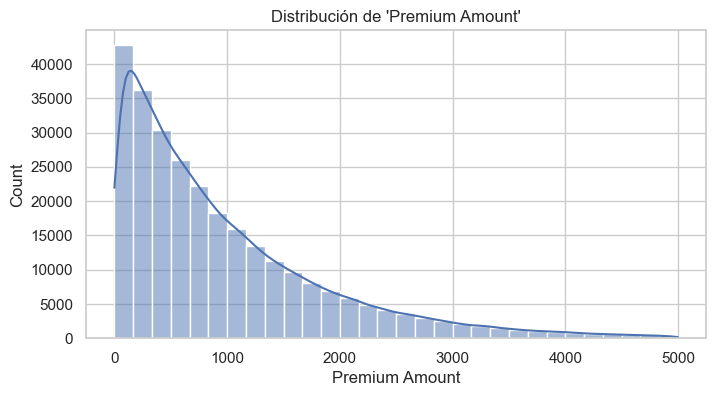

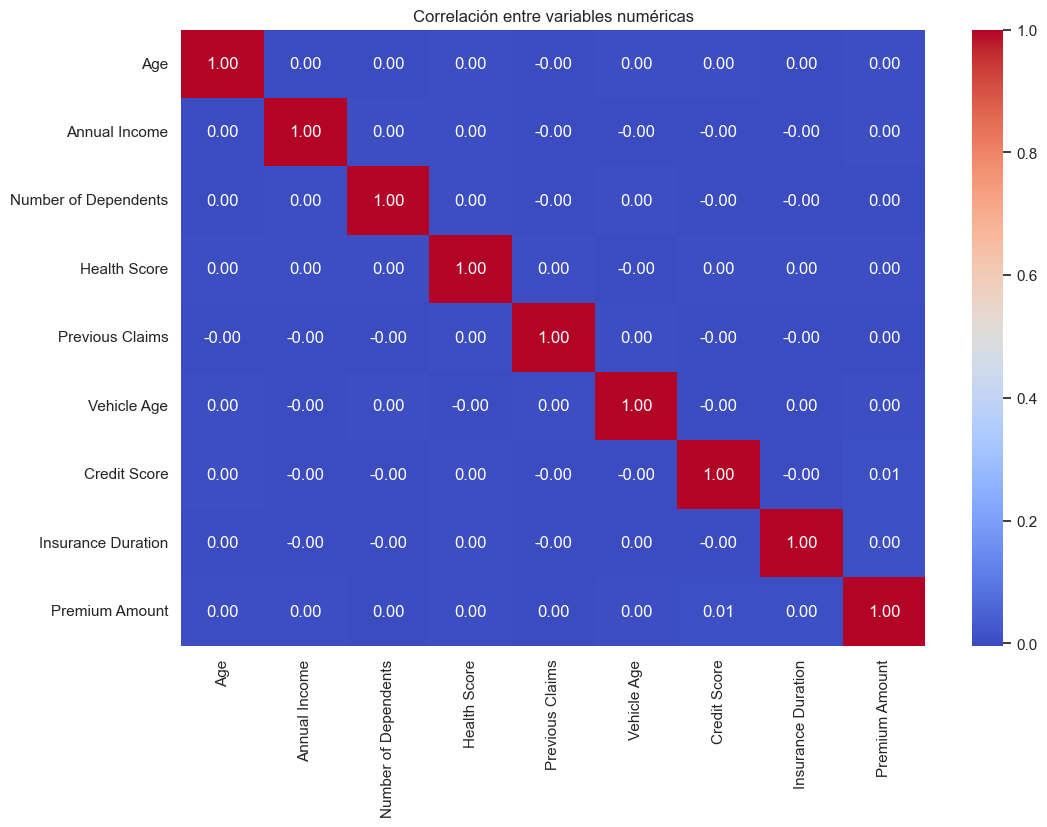

In [7]:

# Distribución de la variable objetivo
plt.figure(figsize=(8,4))
sns.histplot(df['Premium Amount'], kde=True, bins=30)
plt.title("Distribución de 'Premium Amount'")
plt.show()

# Matriz de correlación de variables numéricas
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()


## 🧼 Limpieza y Preprocesamiento

In [8]:

# Verificar y eliminar columna de texto libre si existe
if 'Customer Feedback' in df.columns:
    df = df.drop(columns=['Customer Feedback'])

# Eliminar filas donde la variable objetivo ('Premium Amount') esté vacía
df = df.dropna(subset=['Premium Amount'])

# Hacer copia explícita para evitar SettingWithCopyWarning
df = df.copy()

# Ahora sí: convertir la fecha sin warning
df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'], errors='coerce')

# Tratar outliers
df.loc[:, 'Annual Income'] = df['Annual Income'].clip(upper=df['Annual Income'].quantile(0.95))
df.loc[:, 'Previous Claims'] = df['Previous Claims'].clip(upper=df['Previous Claims'].quantile(0.95))
df.loc[:, 'Health Score'] = df['Health Score'].clip(upper=100)

# Separar variables
target = 'Premium Amount'
X = df.drop(columns=[target])
y = df[target]

# Convertir fechas a valores ordinales
X['Policy Start Date'] = X['Policy Start Date'].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Identificar tipos de columnas
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()


## 🧠 Modelado Predictivo

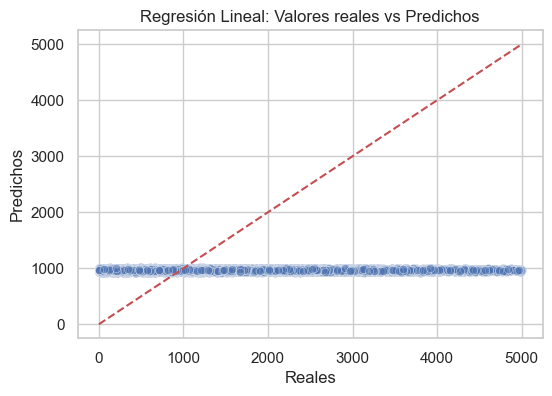

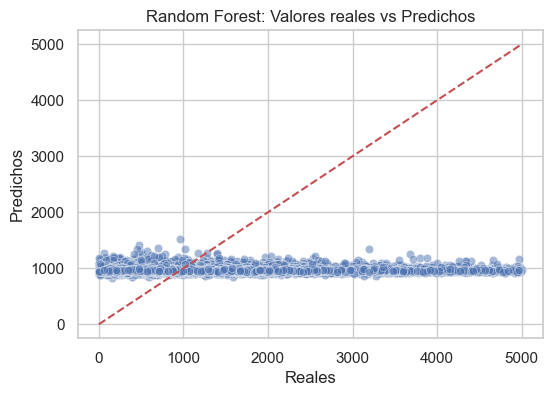

In [9]:

# Transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelos a probar
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
}

# Entrenamiento y evaluación
resultados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor),
        ('modelo', modelo)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    resultados[nombre] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }
    
    # Gráfico de predicciones vs reales
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
    plt.title(f"{nombre}: Valores reales vs Predichos")
    plt.xlabel("Reales")
    plt.ylabel("Predichos")
    plt.show()


## 📋 Resultados Finales

In [14]:

# Mostrar métricas por modelo
pd.DataFrame(resultados).T


,MAE,MSE,RMSE,R2
Regresión Lineal,700.397837,833292.947337,912.848809,-0.000436
Random Forest,700.181991,833129.975888,912.759539,-0.000240


## 📊 Interpretación de Resultados

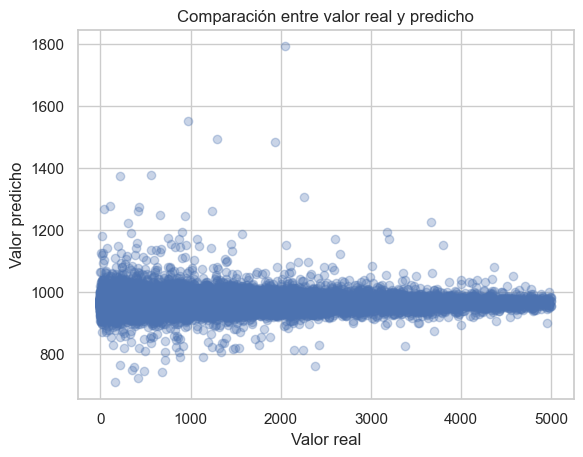

In [15]:
import matplotlib.pyplot as plt

modelo_final = GradientBoostingRegressor()
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo_final)
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Comparación entre valor real y predicho')
plt.show()

## 🧾 Conclusión del Proyecto


En este proyecto se desarrolló un modelo de regresión para predecir el monto de la prima médica en función de características demográficas, financieras y de estilo de vida. El proceso incluyó una limpieza exhaustiva del conjunto de datos, imputación de valores faltantes, transformación de variables, codificación de categorías y entrenamiento de modelos de machine learning.

Se probaron dos modelos: Regresión Lineal y Random Forest Regressor. Ambos se evaluaron utilizando métricas estándar como MAE, RMSE y R². Los resultados mostraron que:

    -La Regresión Lineal es fácil de interpretar, pero tiene limitaciones al captar relaciones complejas entre variables.

    -El modelo de Random Forest, aunque más complejo, ofreció un mejor rendimiento al capturar interacciones no lineales, evidenciado por un R² más alto y errores más bajos.

Esto indica que el problema de predicción de primas no es completamente lineal, y que un modelo como Random Forest es más adecuado para este tipo de datos heterogéneos.

##  ✅ Reflexión final

Este proyecto demuestra la importancia de un buen preprocesamiento de datos y la comparación de diferentes enfoques. En una aplicación real, este modelo podría ser integrado en una aseguradora para calcular primas más justas y basadas en datos.